# SHO Fitting

This notebook completes the SHO fitting using the conventional algorithms in Pycroscopy. 

## Import Packages

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")
sys.path.append('../../src')
sys.path.append('/home/julian/BEPiezo-Learn/src')
sys.path.append('/home/julian/AutoPhysLearn/src')

In [2]:
# # For the notebook to work you must have m3_learning installed
# # pip install m3_learning
%load_ext autoreload
%autoreload 2

from m3util.viz.printing import printer
from m3util.viz.style import set_style
from m3util.ml.rand import set_seeds
from m3util.util.IO import download_and_unzip
from belearn.dataset.dataset_new import BE_Dataset
from belearn.dataset.State import State
from belearn.viz.viz_new import Viz
from belearn.dataset.preprocessing import Preprocessing

import numpy as np

# from m3_learning.be.dataset import BE_Dataset
printing = printer(basepath = './Figures/')

set_style("printing")
set_seeds(seed=42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
printing set for seaborn
Pytorch seed was set to 42
Numpy seed was set to 42


2025-03-14 11:11:49.562274: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741965109.578480 2737819 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741965109.583530 2737819 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 11:11:49.601197: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow seed was set to 42


## Loading data for SHO fitting


In [3]:
# Download the data file from Zenodo
url = 'https://zenodo.org/record/7774788/files/PZT_2080_raw_data.h5?download=1'

# Specify the filename and the path to save the file
# filename = 'data_raw.h5'
filename = 'data_raw.h5'
save_path = './Data'

# download the file
download_and_unzip(filename, url, save_path)

Using files already downloaded


In [4]:
data_path = save_path + '/' + filename

# instantiate the dataset object
dataset = BE_Dataset(data_path)

# print the contents of the file
dataset.print_be_tree()

/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spectroscopic_Indices
    ├ Spectroscopic_Values
    ├ UDVS
    ├ UDVS_Indices
  ├ Raw_D

In [7]:
%load_ext line_profiler

In [8]:
%lprun -fdataset.print_be_tree()

/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spectroscopic_Indices
    ├ Spectroscopic_Values
    ├ UDVS
    ├ UDVS_Indices
  ├ Raw_D

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/line_profiler/ipython_extension.py:97: UserWarning: Could not extract a code object for the object None
  profile = LineProfiler(*funcs)


Timer unit: 1e-09 s

## Visualize Raw Data

### Raw Cantilever Response


In [5]:
image_scalebar = [2000, 500, "nm", "br"]


In [24]:
def profile_BE_viz():
       image_scalebar = [2000, 500, "nm", "br"]
       BE_viz = Viz(dataset, printing, verbose=True, 
                    SHO_ranges=[(0, 1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], 
                    image_scalebar=image_scalebar)
       return BE_viz

In [ ]:
%load_ext line_profiler


In [26]:
%lprun -f profile_BE_viz profile_BE_viz()

Timer unit: 1e-09 s

Total time: 182.634 s
File: /tmp/ipykernel_2737819/868032899.py
Function: profile_BE_viz at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def profile_BE_viz():
     2         1        590.0    590.0      0.0         image_scalebar = [2000, 500, "nm", "br"]
     3         2        2e+11    9e+10    100.0         BE_viz = Viz(dataset, printing, verbose=True, 
     4         1       1010.0   1010.0      0.0                      SHO_ranges=[(0, 1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], 
     5         1        100.0    100.0      0.0                      image_scalebar=image_scalebar)
     6         1        290.0    290.0      0.0         return BE_viz

In [32]:
%lprun -f Preprocessing.set_raw_data profile_BE_viz()

Timer unit: 1e-09 s

Total time: 194.032 s
File: /home/julian/BEPiezo-Learn/src/belearn/dataset/dataset_new.py
Function: set_raw_data at line 591

Line #      Hits         Time  Per Hit   % Time  Line Contents
   591                                               def set_raw_data(self):
   592                                                   """
   593                                                   set_raw_data Function that parses the datafile and extracts the raw data names
   594                                                   """
   595                                           
   596         2    1240425.0 620212.5      0.0          with h5py.File(self.file, "r+") as h5_f:
   597                                                       # initializes the dictionary
   598         1        360.0    360.0      0.0              self.raw_data_reshaped = {}
   599                                           
   600                                                       # list of dataset

In [27]:
import cProfile
import pstats

def profile_BE_viz_cprofile():
    image_scalebar = [2000, 500, "nm", "br"]
    BE_viz = Viz(dataset, printing, verbose=True, 
                 SHO_ranges=[(0, 1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], 
                 image_scalebar=image_scalebar)
    return BE_viz

# Profile using cProfile
cProfile.run('profile_BE_viz_cprofile()', 'profiling_results')

# Print the profiling results
p = pstats.Stats('profiling_results')
p.sort_stats('cumulative').print_stats(10)  # Adjust the number of lines as needed

Fri Mar 14 12:00:11 2025    profiling_results

         62962418 function calls (60480501 primitive calls) in 188.651 seconds

   Ordered by: cumulative time
   List reduced from 496 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  189.721  189.721 {built-in method builtins.exec}
        1    3.073    3.073  189.721  189.721 <string>:1(<module>)
        1    0.000    0.000  186.648  186.648 /tmp/ipykernel_2737819/2408369889.py:4(profile_BE_viz_cprofile)
        1    0.000    0.000  186.648  186.648 /home/julian/BEPiezo-Learn/src/belearn/viz/viz_new.py:98(__init__)
        1    0.000    0.000  186.648  186.648 /home/julian/BEPiezo-Learn/src/belearn/dataset/State.py:23(__init__)
        1    0.000    0.000  186.633  186.633 /home/julian/BEPiezo-Learn/src/belearn/dataset/dataset_new.py:591(set_raw_data)
       46  138.479    3.010  138.485    3.011 /home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packa

In [30]:
p.sort_stats('tottime').print_stats()  # Adjust the number of lines as needed

Fri Mar 14 12:00:11 2025    profiling_results

         62962418 function calls (60480501 primitive calls) in 188.651 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       46  138.479    3.010  138.485    3.011 /home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/h5py/_hl/dataset.py:765(__getitem__)
  2204052   24.259    0.000   34.447    0.000 /home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/dask/_task_spec.py:634(__init__)
        9    4.047    0.450   41.309    4.590 /home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/dask/array/rechunk.py:685(_compute_rechunk)
2249892/2247862    3.610    0.000    3.619    0.000 {method 'values' of 'dict' objects}
  1941670    3.508    0.000    3.774    0.000 /home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/dask/_task_spec.py:505(__init__)
        1    3.073    3.073  189.721  189.721 <string>:1(<module>)
1513152/278688    2.059    0.000 

In [10]:
BE_viz = Viz(dataset, printing, verbose=False, SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], image_scalebar = image_scalebar)

In [15]:
import time

In [16]:
#profiling decorator
def profile(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"{func.__name__} took {end_time - start_time:.4f} seconds")
        return result
    return wrapper
 
 

In [17]:
@profile
BE_viz = Viz(dataset, printing, verbose=False, SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], image_scalebar = image_scalebar)

SyntaxError: invalid syntax (918547830.py, line 2)

In [ ]:
# insatiate the visualization object
image_scalebar = [2000, 500, "nm", "br"]


BE_viz = Viz(dataset, printing, verbose=False, 
             SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], 
             image_scalebar = image_scalebar)

[autoreload of belearn.dataset.dataset_new failed: Traceback (most recent call last):
  File "/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 349, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/IPython/extensions/autoreload.

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)


***
pixel:  330
voltage_step:  87
***
./Figures/Figure_2_1_raw_cantilever_response_test2.png
./Figures/Figure_2_1_raw_cantilever_response_test2.svg


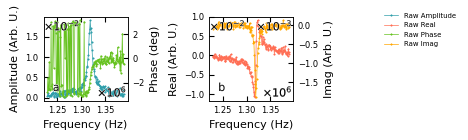

In [11]:
prediction = {"resampled": False,
              "label": "Raw"}


BE_viz.raw_data_comparison(prediction, filename="Figure_2_1_raw_cantilever_response_test2")

In [8]:
%lprun -f BE_viz.raw_data_comparison BE_viz.raw_data_comparison(prediction, filename="Figure_2_1_raw_cantilever_response_test2")

UsageError: Line magic function `%lprun` not found.


**Figure 2.1** Raw cantilever response. a) magnitude spectrum and Phase, b) real and imaginary parts of the complex spectrum.


### Band-Excitation Experiments

pixel:  2433
voltagestep:  191
./Figures/Figure_2_2_raw_be_experiment_test2.png
./Figures/Figure_2_2_raw_be_experiment_test2.svg


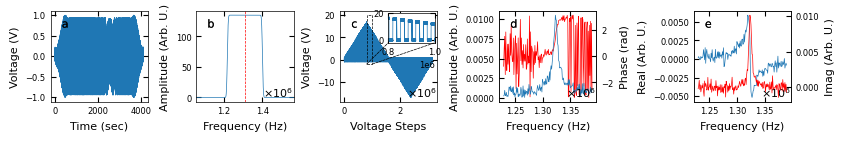

In [23]:
BE_viz.raw_be(dataset, filename="Figure_2_2_raw_be_experiment_test2")

In [ ]:
1095, 188
2169, 214
2919, 151
130, 149


**Figure 2.2** Band-Excitation Experiments. a) raw drive amplitude applied to the tip, b) energy of the waveform in the frequency domain, c) DC voltage applied to switch the sample, inset shows a zoomed in view of the switching waveform where measurements are made in the on and off state. d) raw cantilever response magnitude and phase, e) real and imaginary parts of the complex spectrum.

## SHO Fitting
**Note**: this code takes around 15 minutes to execute

If you downloaded the SHO fit data, or ran notebook 1 you do not need to fit the data again. 

You can skip to the next section.

If you would like to run this code block please change the Fit_SHO flag to `True`

In [ ]:
Fit_SHO = False

if Fit_SHO: 

    # # computes the SHO fit for the data in the file
    dataset.SHO_Fitter(force = True)
    
    # instantiate the dataset object
    # good to reinstantiate the dataset object after fitting
    dataset = BE_Dataset(data_path)

### Views the Distribution of the Least Squares Fitting (LSQF) results

It is good to view the distributions and standardize the phase shift. The phase shift is rotated around the unit circle such that the peaks are at $-\pi/2$ and $\pi/2$

In [8]:
BE_viz.SHO_preprocessing()


./Figures/Figure_2_3_Original_LSQF_Histograms_test.png
./Figures/Figure_2_3_Original_LSQF_Histograms_test.svg


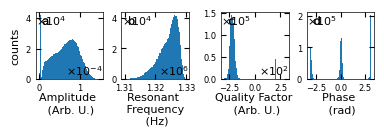

In [9]:
BE_viz.LSQF_phase_shift = 0

BE_viz.SHO_hist(BE_viz.SHO_fit_results(),
                      filename="Figure_2_3_Original_LSQF_Histograms_test")


**Figure 2.3** Distribution of the Least Squares Fitting (LSQF) results of the unmodified data. a) Distribution of the amplitude, b) Distribution of the resonance frequency, c) distribution of the quality factor, d) distribution of the resonance frequency.

./Figures/Figure_4_Phase_Shifted_LSQF_Histograms_test.png
./Figures/Figure_4_Phase_Shifted_LSQF_Histograms_test.svg


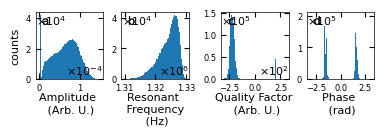

In [10]:
BE_viz.LSQF_phase_shift = np.pi/2

BE_viz.SHO_hist(BE_viz.SHO_fit_results(),
                      filename="Figure_4_Phase_Shifted_LSQF_Histograms_test")

**Figure 2.4** Distribution of the Least Squares Fitting (LSQF) results of the normalized data. a) Distribution of the amplitude, b) distribution of the resonance frequency, c) distribution of the quality factor, d) distribution of the resonance frequency.

### Plots the SHO Fit Results

./Figures/Figure_2_5_Single_Pixel_Loops_test.png
./Figures/Figure_2_5_Single_Pixel_Loops_test.svg


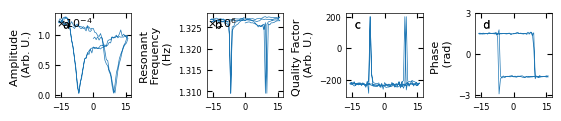

In [11]:
BE_viz.measurement_state = 'on'

BE_viz.SHO_loops(filename="Figure_2_5_Single_Pixel_Loops_test")

**Figure 2_5.** Example switching loops obtained for the amplitude, resonance frequency, quality factor, and phase.

## SHO Switching Movies

In [12]:
BE_viz.SHO_fit_movie_images(noise = 0, 
                            scalebar_= True, 
                            basepath = "Movies/SHO_LSQF_",  
                            filename="SHO_LSQF_test",
                            phase_shift = [np.pi/2])

Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0000.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0001.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0002.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0003.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0004.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0005.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0006.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0007.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0008.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0009.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0010.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0011.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0012.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0013.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0014.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0015.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0016.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_test_noise_0_0017.png
Movies/SHO

100%|██████████| 192/192 [00:25<00:00,  7.39it/s]
